# Task 1: Data preparation

### 1A: Exploratory data analysis

In [57]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sb

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

In [60]:
df_mood = pd.read_csv('dataset_mood_smartphone.csv')
df_mood

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


In [3]:
print(df_mood.id.unique())

time_measures = []
for id in df_mood.id.unique():
    id_df = df_mood[df_mood.id == id]
    time_measures.append(len(id_df.time.unique()))

print(sorted(time_measures))

<ArrowStringArray>
['AS14.01', 'AS14.02', 'AS14.03', 'AS14.05', 'AS14.06', 'AS14.07', 'AS14.08',
 'AS14.09', 'AS14.12', 'AS14.13', 'AS14.14', 'AS14.15', 'AS14.16', 'AS14.17',
 'AS14.19', 'AS14.20', 'AS14.23', 'AS14.24', 'AS14.25', 'AS14.26', 'AS14.27',
 'AS14.28', 'AS14.29', 'AS14.30', 'AS14.31', 'AS14.32', 'AS14.33']
Length: 27, dtype: str
[2270, 3096, 3429, 6829, 8743, 10321, 10689, 10795, 11055, 12188, 13657, 13738, 13939, 14100, 15023, 15133, 15474, 15490, 15777, 16434, 16716, 16809, 17334, 18720, 18884, 20985, 21298]


In [4]:
df_mood.variable.unique()

<ArrowStringArray>
[                'mood',   'circumplex.arousal',   'circumplex.valence',
             'activity',               'screen',                 'call',
                  'sms',       'appCat.builtin', 'appCat.communication',
 'appCat.entertainment',       'appCat.finance',          'appCat.game',
        'appCat.office',         'appCat.other',        'appCat.social',
        'appCat.travel',       'appCat.unknown',     'appCat.utilities',
       'appCat.weather']
Length: 19, dtype: str

#### 1A.1 Ranges of values

In [5]:
for variable in df_mood.variable.unique():
    var_df = df_mood[df_mood.variable == variable]
    print(f'{variable}, min: {sorted(var_df.value)[0]}, max: {sorted(var_df.value)[-1]}')

mood, min: 1.0, max: 10.0
circumplex.arousal, min: -2.0, max: 2.0
circumplex.valence, min: -2.0, max: 2.0
activity, min: 0.0, max: 1.0
screen, min: 0.0350000858306885, max: 9867.00699996948
call, min: 1.0, max: 1.0
sms, min: 1.0, max: 1.0
appCat.builtin, min: -82798.871, max: 33960.246
appCat.communication, min: 0.006, max: 9830.777
appCat.entertainment, min: -0.011, max: 32148.677
appCat.finance, min: 0.131, max: 355.513
appCat.game, min: 1.003, max: 5491.793
appCat.office, min: 0.003, max: 32708.818
appCat.other, min: 0.014, max: 3892.038
appCat.social, min: 0.094, max: 30000.906
appCat.travel, min: 0.08, max: 10452.615
appCat.unknown, min: 0.111, max: 2239.937
appCat.utilities, min: 0.246, max: 1802.649
appCat.weather, min: 1.003, max: 344.863


#### 1A.2 Missing values

In [6]:
# check whether there are any missing values in not 'value' column
df_mood.info()
# only in the last column, there are missing values
# 376912 - 376710 = 202 missing values

<class 'pandas.DataFrame'>
RangeIndex: 376912 entries, 0 to 376911
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  376912 non-null  int64  
 1   id          376912 non-null  str    
 2   time        376912 non-null  str    
 3   variable    376912 non-null  str    
 4   value       376710 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 29.8 MB


[np.int64(0), np.int64(46), np.int64(156), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
202


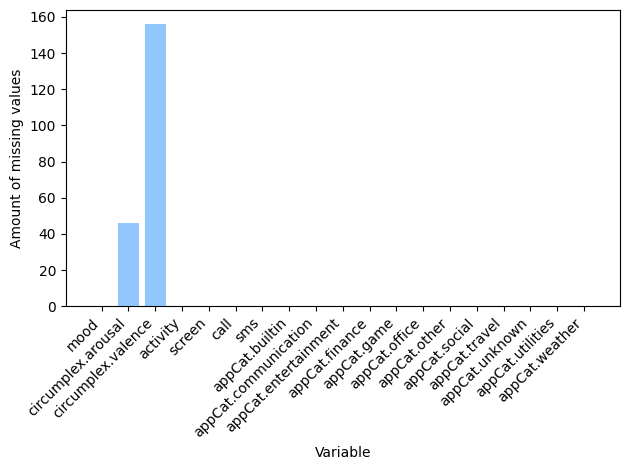

In [7]:
# missing values per variable
variables = df_mood.variable.unique()
missing = []
for variable in variables:
    var_df = df_mood[df_mood.variable == variable]
    missing.append(var_df["value"].isnull().sum())

# missing list adds up to 202:
print(missing)
print(sum(missing))

# plot distribution for this

fig, ax = plt.subplots()

ax.bar(variables, missing)
ax.set_ylabel("Amount of missing values")
ax.set_xlabel("Variable")
ax.tick_params("x", rotation = 45)

plt.setp(ax.get_xticklabels(), ha = "right")
plt.tight_layout()

    

202


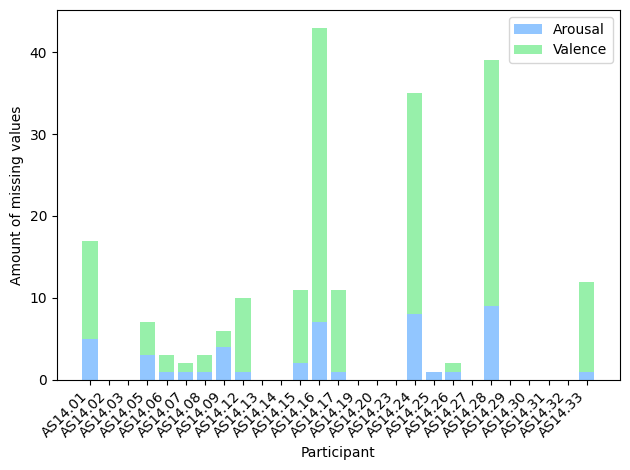

In [8]:
# missing values per participant
ids = df_mood.id.unique()
missing = []

missing_counts = {'Arousal': [], 'Valence': []}

for id in ids:
    #define df for this id
    id_df = df_mood[df_mood.id == id]

    # count missing values in arousal
    id_arouse_df = id_df[id_df.variable == 'circumplex.arousal']
    missing_counts['Arousal'].append(id_arouse_df["value"].isnull().sum())

    #count missing values in valence
    id_valence_df = id_df[id_df.variable == 'circumplex.valence']
    missing_counts['Valence'].append(id_valence_df['value'].isnull().sum())
   
# missing list adds up to 202:
print(sum(missing_counts['Arousal']) + sum(missing_counts['Valence']))

# plot distribution for this

fig, ax = plt.subplots()
bottom = np.zeros(len(ids))

for variable, counts in missing_counts.items():
    p = ax.bar(ids, counts, label = variable, bottom = bottom)
    bottom += counts
    # ax.bar_label(p, label_type = 'center')

# ax.bar(ids, missing)
ax.set_ylabel("Amount of missing values")
ax.set_xlabel("Participant")
ax.tick_params("x", rotation = 45)
ax.legend()

plt.setp(ax.get_xticklabels(), ha = "right")
plt.tight_layout()

#### 1A.3 Distribution of values

In [ ]:
# disribution of all values 

fig, ax = plt.subplots()
ax.hist(df_mood.value)
ax.set_yscale('log', base = 10)
ax.set_xlabel(f'Values')
ax.set_ylabel('count')

Text(0, 0.5, 'Count')

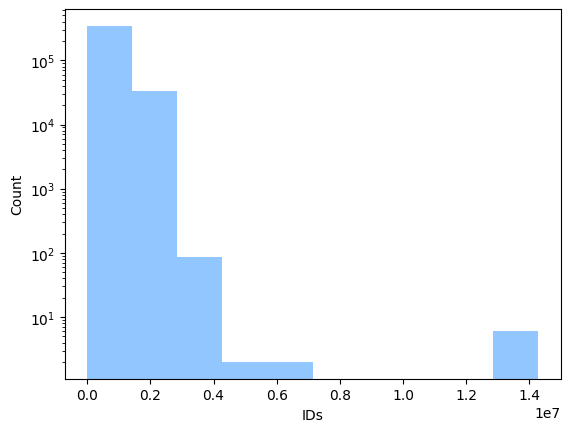

In [10]:
# distribution of ids

fig, ax = plt.subplots()
ax.hist(df_mood["Unnamed: 0"])
ax.set_yscale('log', base = 10)
ax.set_xlabel(f'IDs')
ax.set_ylabel('Count')

In [ ]:
# distribution of values for each variable
for variable in df_mood.variable.unique():
    var_df = df_mood[df_mood.variable == variable]

    fig, ax = plt.subplots()
    ax.hist(var_df.value, bins = 20)
    ax.set_yscale('log', base = 10)
    ax.set_xlabel(f'{variable}')
    ax.set_ylabel('Count')

#### 1A.4 Relationships between attributes

In [12]:
# remove unusual instances before we do correlation testing
builtin = [-82798.871, -44.689, -1.218]
entertain = [-0.011]

# print(df_mood.loc[df_mood['value'] == builtin[0]])
# print(df_mood.loc[df_mood['value'] == builtin[1]])
# print(df_mood.loc[df_mood['value'] == builtin[2]])
# print(df_mood.loc[df_mood['value'] == entertain])

df_mood_filt = df_mood[~df_mood["value"].isin(builtin)]
df_mood_filt = df_mood_filt[~df_mood_filt["value"].isin(entertain)]

df_mood_filt = df_mood_filt.dropna(axis = 0)
df_mood_filt

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


In [13]:
df_var_val = df_mood_filt.iloc[:, [3,4]]

df_pivoted = df_var_val.pivot_table(index=df_var_val.groupby('variable').cumcount(), 
                             columns='variable', 
                             values='value')

df_pivoted.columns.name = None
df_pivoted = df_pivoted.reset_index(drop=True)

# I want to move the mood column to the end of this dataframe
cols = [c for c in df_pivoted.columns if c != 'mood'] + ['mood']
df_pivoted = df_pivoted[cols]

df_pivoted



,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,screen,sms,mood
0,0.071429,2.288,4.190,6.211,4.012,41.125,62.281,10.343,61.641,14.067,45.173,1.002,30.386,1.0,-1.0,0.0,58.846,1.0,6.0
1,0.091667,1.007,2.009,2.004,8.157,191.911,5.479,1.002,120.396,57.238,1.003,20.072,44.854,1.0,-1.0,1.0,9.217,1.0,6.0
2,0.008333,37.125,30.286,34.378,6.027,51.176,104.446,38.160,68.216,5.010,39.134,3.011,29.890,1.0,0.0,1.0,19.829,1.0,6.0
3,0.000000,1.003,16.054,55.239,4.007,102.930,3.010,41.542,56.169,21.521,9.755,271.173,2.065,1.0,1.0,1.0,483.510,1.0,7.0
4,0.000000,4.017,13.053,144.711,8.082,3.006,68.235,13.045,2.004,428.503,5.500,3.017,1.574,1.0,-2.0,0.0,812.907,1.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.394,NaN,NaN
96574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,164.072,NaN,NaN
96575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,504.017,NaN,NaN
96576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,526.137,NaN,NaN


                      activity  appCat.builtin  appCat.communication  \
activity              1.000000        0.001450              0.003952   
appCat.builtin        0.001450        1.000000             -0.001273   
appCat.communication  0.003952       -0.001273              1.000000   
appCat.entertainment  0.004769       -0.001071             -0.000428   
appCat.finance       -0.043258        0.008479             -0.049801   
appCat.game          -0.007323       -0.014769              0.023687   
appCat.office         0.006270       -0.001100             -0.006907   
appCat.other         -0.007559        0.001127              0.005565   
appCat.social        -0.011933       -0.003358              0.004567   
appCat.travel         0.016985       -0.005014             -0.017048   
appCat.unknown       -0.003690       -0.014438             -0.031314   
appCat.utilities      0.008977        0.005026             -0.023791   
appCat.weather        0.006164       -0.016035             -0.05

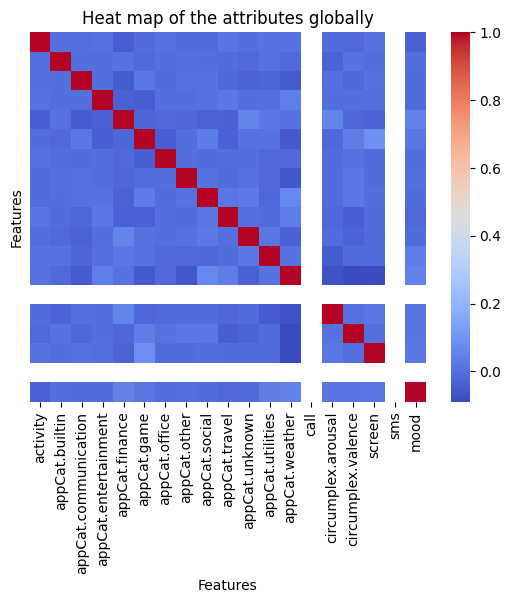

In [14]:

corr_mtx = df_pivoted.corr(numeric_only=True)
print(corr_mtx)

corr_plot = sb.heatmap(corr_mtx, cmap = "coolwarm")
# plt.xticks([df_pivoted.columns])
# plt.tick_params("x", rotation = 45)
plt.yticks([])
plt.xlabel('Features')
plt.ylabel('Features')
plt.title('Heat map of the attributes globally')
plt.show()

In [15]:
corr_mtx.max()

activity                1.0
appCat.builtin          1.0
appCat.communication    1.0
appCat.entertainment    1.0
appCat.finance          1.0
appCat.game             1.0
appCat.office           1.0
appCat.other            1.0
appCat.social           1.0
appCat.travel           1.0
appCat.unknown          1.0
appCat.utilities        1.0
appCat.weather          1.0
call                    NaN
circumplex.arousal      1.0
circumplex.valence      1.0
screen                  1.0
sms                     NaN
mood                    1.0
dtype: float64

Call and sms are not correlating with any other variables cause they are just 1s. 

#### 1A.5 Relationships between mood and attribute

This can be seen above, mood does not correlate highly with any of the other variables. 

#### 1A.6 Split dataset into participant data????

#### 1A Summary

There are 276911 instances (without headers) in the raw data and 5 colomns
- 27 participants

Amount of measures in time differs for the participants. Ranging from 2270 times, to 21298 times

19 attributes in the 'variable' column

### 1B: Data cleaning

First remove the outliers

The outliers are:
- appCat.builtin: three values: -82798.871 and -44.689 and -1.218
- appCat.entertainment: -0.011

I think they all need to be removed? Or we could choose to make them zero, but I think in the case of -82798.871 that is weird so maybe it would be better to just remove all of these.

In [16]:
df_mood = pd.read_csv('dataset_mood_smartphone.csv')

# remove unusual instances before we do correlation testing
to_remove = [-82798.871, -44.689, -1.218, -0.011]

# check if these values occur only once
for value in to_remove:
    count = df_mood["value"].value_counts().get(value, 0)
    print(f"{value} appears {count} time(s)")


df_mood_filt = df_mood[~df_mood["value"].isin(to_remove)]
df_mood_filt

-82798.871 appears 1 time(s)
-44.689 appears 1 time(s)
-1.218 appears 1 time(s)
-0.011 appears 1 time(s)


,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


#### 1B.1 Imputing missing data

It says: select two approaches to imput missing values that are logical for such time series and argue for one of them based on the insights you gain. 

Consider what to do with prolonged periods of missing data in a time series.


In [ ]:
# Because of this last remark, first plot the data for the two variables that are missing values

# find participants for which there is data missing
# missing values per participant
ids = df_mood_filt.id.unique()
ids_withmiss = []

missing_counts = {'Arousal': [], 'Valence': []}

for id in ids:
    #define df for this id
    id_df = df_mood_filt[df_mood_filt.id == id]
    if id_df['value'].isnull().sum() > 0:
        ids_withmiss.append(id)

print(ids_withmiss)

# plot that data (lines?)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for id in ids_withmiss:

    id_df = df_mood_filt[df_mood_filt.id == id]
    valence_df = id_df[id_df['variable'] == 'circumplex.valence']
    arousal_df = id_df[id_df['variable'] == 'circumplex.arousal']
    fig1, axs = plt.subplots(2, 1,  figsize=(15, 4))
    axs[0].plot(arousal_df['value'], 'o-', color = colors[0])
    axs[0].set_ylabel("Arousal")
    axs[1].plot(valence_df['value'], 'o-', color = colors[1])
    axs[1].set_ylabel("Valence")
    axs[1].set_xlabel("Time")

    fig1.suptitle(id)


    for ax in axs:
        ax.tick_params(axis='x', which='both', labelbottom=False, bottom=False)
    plt.show()



# later impute the data and compare



Dataprep:

In [ ]:
# We want to impute data only based on that participant

# split df in df_valence_arouse and df_everything_else
df_other = df_mood_filt.loc[(df_mood_filt['variable'] != 'circumplex.arousal') & (df_mood_filt['variable'] != 'circumplex.valence')]

df_val = df_mood_filt.loc[(df_mood_filt['variable'] == 'circumplex.valence')]
df_ar = df_mood_filt.loc[(df_mood_filt['variable'] == 'circumplex.arousal')]

##### 1B.1.1 Rolling statistics
 
window, and use a statistic to estimate the value

##### 1B.1.2

KNN
https://www.sciencedirect.com/science/article/pii/S2352914823002289

In [ ]:
from sklearn.impute import KNNImputer

# First find the missing values for each participant, and impute the data
def impute_KNN(df, valid = [-2.0, -1.0, 0.0, 1.0, 2.0]):
    new_df = pd.DataFrame(columns = df.columns)
    for id in df.id.unique():
        id_df = df[df.id == id]
        # check whether or not there are missing values here
        if id_df.value.isnull().sum() > 0:
            # impute data
            values = np.array(id_df.value.tolist()).reshape(-1,1)
            # print(values)
            knn = KNNImputer(n_neighbors=2, weights="uniform")
            X = knn.fit_transform(values)
            X = X.reshape(1, -1)[0]
            print(X)

            for i in range(len(X)):
                if X[i] not in valid:
                    X[i] = float(round(X[i]))
            id_df.value = X
            id_df_new = id_df

        else:
            id_df_new = id_df

        new_df = pd.concat([new_df, id_df_new])
    
    return new_df


# Impute the values and get the new and imputed dataframes (for valence and arousal only)
df_imputed_val = impute_KNN(df_val)
df_imputed_ar = impute_KNN(df_ar)

# Concatenate to one dataframe
df_KNN_imputed = pd.concat([df_other, df_imputed_val, df_imputed_ar])



##### Median

In [ ]:
from sklearn.impute import SimpleImputer

# First find the missing values for each participant, and impute the data
def impute_simple(df, valid = [-2.0, -1.0, 0.0, 1.0, 2.0]):
    new_df = pd.DataFrame(columns = df.columns)
    for id in df.id.unique():
        id_df = df[df.id == id]

        # check whether or not there are missing values here
        if id_df.value.isnull().sum() > 0:
            # impute data
            # values = np.array(id_df.value.tolist()).reshape(-1,1)


            # print(values)
            simp = SimpleImputer(strategy = "median")
            X = simp.fit_transform(values)
            X = X.reshape(1, -1)[0]
            print(X)

            for i in range(len(X)):
                if X[i] not in valid:
                    X[i] = float(round(X[i]))
            id_df.value = X
            id_df_new = id_df

        else:
            id_df_new = id_df

        new_df = pd.concat([new_df, id_df_new])
    
    return new_df


# Impute the values and get the new and imputed dataframes (for valence and arousal only)
df_imputed_val = impute_KNN(df_val)
df_imputed_ar = impute_KNN(df_ar)

# Concatenate to one dataframe
df_KNN_imputed = pd.concat([df_other, df_imputed_val, df_imputed_ar])


df = pd.DataFrame([["a", "x"],
                   [np.nan, "y"],
                   ["a", np.nan],
                   ["b", "y"]], dtype="category")

imp = SimpleImputer(strategy="most_frequent")
print(imp.fit_transform(df))
[['a' 'x']
 ['a' 'y']
 ['a' 'y']
 ['b' 'y']]